# Pre-processing

To pre-process the data we will load it in, and split it into tracks. We will extract key attributes from the files that will be used in the training and prediction process

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import io
import json
from shapely.geometry import shape, Point, Polygon

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/mhen/.local/share/fonts/IBMPlexSerif-Regular.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.sans-serif"] = [font_prop.get_name()]

import cartopy.crs as ccrs
import cartopy.feature as cfeat

from datetime import datetime, timedelta
from GPSat import get_data_path, get_parent_path
from GPSat.dataprepper import DataPrep
from GPSat.utils import WGS84toEASE2_New, EASE2toWGS84_New, cprint, grid_2d_flatten, get_weighted_values
from GPSat.local_experts import LocalExpertOI, get_results_from_h5file
from GPSat.plot_utils import plot_pcolormesh, get_projection, plot_pcolormesh_from_results_data
from GPSat.postprocessing import smooth_hyperparameters
import GPSat
from GPSat.postprocessing import glue_local_predictions_1d
from GPSat.postprocessing import glue_local_predictions_2d

2026-05-15 13:41:31.863285: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-15 13:41:40.215150: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-15 13:41:40.215236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-15 13:41:40.669496: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 13:41:41.551171: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def GCdist(X,Xs):
    '''Finds the great circle distance along a line of lon-lat co-ordinates.'''
    radius = lambda lat : np.sqrt(((6378137**2 * np.cos(lat))**2 + (6356752**2 * np.sin(lat))**2/\
                                  (6378137 * np.cos(lat))**2 + (6356752 * np.sin(lat))**2))

    minlat = min(np.min(X.T[(1,)].T),np.min(Xs.T[(1,)].T))
    maxlat = max(np.max(X.T[(1,)].T),np.max(Xs.T[(1,)].T))
    lon1 = np.radians(X.T[(0,)].T) ; lat1 = np.radians(X.T[(1,)].T)
    lon2 = np.radians(Xs.T[(0,)].T) ; lat2 = np.radians(Xs.T[(1,)].T)
    r = 6356752#np.mean(radius(np.arange(minlat,maxlat)))

    Clat1 = np.cos(lat1) ; Clat2 = np.cos(lat2)
    Slat1 = np.sin(lat1) ; Slat2 = np.sin(lat2)
    Clon1 = np.cos(lon1) ; Clon2 = np.cos(lon2)
    Slon1 = np.sin(lon1) ; Slon2 = np.sin(lon2)

    n1 = np.array([Clat1*Clon1,Clat1*Slon1,Slat1]).T
    n2 = np.array([Clat2*Clon2,Clat2*Slon2,Slat2]).T
    d = np.dot(n1,n2.T)
    d = np.clip(d, -1., 1.)
    return r*np.arccos(d)

We locate the data from the directory they are located in.

### Loading data

In [3]:
###############################load in sat data##############################
home_dir = os.getcwd()
data_dir = '/home/cjn/OI_PolarSnow/EASE/data/LARM/CS2S3'

print('Current directory:', home_dir)
print('Switching directory:', data_dir)

#load in csvs
os.chdir(data_dir)
files = os.listdir(data_dir)

bad_substrings = ('._', 'README')  # exclude AppleDouble and README files
files = [f for f in os.listdir(data_dir) 
if not any(s in f for s in bad_substrings)]

#filter to include the months of the date argument and the months either side

#find dates of each file
file_dates = []
for file in files:
    file_split = file.split('_')
    file_date = file_split[-2:]
    file_date[1] = file_date[1].replace('.txt','')
    file_date = file_date[0] + '-' + file_date[1]
    file_date = datetime.strptime(file_date, '%Y-%m')
    file_dates.append(file_date.date())

Current directory: /home/mhen/geol0069_final
Switching directory: /home/cjn/OI_PolarSnow/EASE/data/LARM/CS2S3


We will focus on the month of January 2020 for this work, so we define this as our "target month". We use this to select the months either side as well, should we need this for training or extending the experiment.

In [4]:
#choose date as a datetime object
date_centre = datetime(2020,1,1)
print(date_centre)
#and target month
target_month = '2020-01'

2020-01-01 00:00:00


The files can then be found and extracted to a pandas dataframe where they will be given standardised attributes.

In [5]:
#exclude all but desired months using a mask
#shift 15 days backward as date_centre will be on the 1st
timedelta_back = timedelta(days=15)
timedelta_fwd = timedelta(days=32) #guarantees next month
back = date_centre-timedelta_back
fwd = date_centre+timedelta_fwd

#use boolean mask
mask = [
    (file_date.year, file_date.month) in [
        (back.year, back.month),
        (date_centre.year, date_centre.month),
        (fwd.year, fwd.month)
    ]
    for file_date in file_dates
]

dates_keep = [date for date, keep in zip(file_dates, mask) if keep]
files_keep = [file for file, keep in zip(files, mask) if keep]

print(f'Using months:{[date_keep.strftime("%Y-%m") for date_keep in dates_keep]}')
print(f'Using files:{[file_keep for file_keep in files_keep]}')

Using months:['2019-12', '2020-01', '2020-02', '2019-12', '2020-01', '2020-02']
Using files:['ubristol_cryosat2_GPOD_trajectory_rfb_2019_12.txt', 'ubristol_cryosat2_GPOD_trajectory_rfb_2020_01.txt', 'ubristol_cryosat2_GPOD_trajectory_rfb_2020_02.txt', 'ubristol_sentinel3_GPOD_trajectory_rfb_2019_12.txt', 'ubristol_sentinel3_GPOD_trajectory_rfb_2020_01.txt', 'ubristol_sentinel3_GPOD_trajectory_rfb_2020_02.txt']


### Preprocessing

In [6]:
#switch directory...
os.chdir(data_dir)

#read as dataframes then assemble into one

def safe_read_csv(path):

    good_lines = []
    with open(path, "rb") as f:
        for bline in f:
            try:
                bline.decode("utf-8", errors="strict")  # raises on bad bytes
                good_lines.append(bline)
            except UnicodeDecodeError:
                #drop this line
                pass

    df = pd.read_csv(
        io.BytesIO(b"".join(good_lines)),
        encoding="utf-8",          # very permissive; every byte decodes
        on_bad_lines="skip",
        encoding_errors="strict",
        engine="python"             # more tolerant if any quoting is messy
    )
    return df


print(f"Loading {len(files_keep)} files...")
dfs = []
for file in files_keep:
    print(f'Loading {file}...')
    df = safe_read_csv(file)
    if 'cryosat2' in file:
        df['satellite_name'] = 'cs2'
    if 'sentinel3' in file:
        df['satellite_name'] = 'sentinel3'
    dfs.append(df)
    print('Loaded!')


cs2s3 = pd.concat(dfs, ignore_index=True)
print('Files loaded')

#switch back to avoid dumping stuff in another directory
print('Switching directory:', home_dir)
os.chdir(home_dir)

#strip spaces from columns
cs2s3.columns = cs2s3.columns.str.replace(' ','',regex=False)

print(cs2s3.columns)

#remove unneeded columns
cs2s3 = cs2s3[['Year','Month','Day', 'HHMMSS',
                'Latitude', 'Longitude', 'SLA',
                  'Sea_Ice_Class', 'Lead_Class',
                  'satellite_name']]

#remove NaNs from column HHMMSS
cs2s3 = cs2s3.dropna(subset='HHMMSS')

#change Longitude to lon and Latitude to lat
cs2s3 = cs2s3.rename(columns={'Longitude':'lon', 'Latitude':'lat'})


#create co-ordinates for interpolation: x, y, t
cs2s3['x'], cs2s3['y'] = WGS84toEASE2_New(lon = cs2s3['lon'], lat = cs2s3['lat'],
lat_0 = 90, lon_0 = 0)

#create time column with day precision
dt = cs2s3[['Year', 'Month', 'Day']]

dt = pd.to_datetime(dt)
dt_D = dt.values.astype('datetime64[D]').astype(float)
cs2s3['t'] = dt_D
cs2s3['date_string'] = dt.dt.date.astype(str)

Loading 6 files...
Loading ubristol_cryosat2_GPOD_trajectory_rfb_2019_12.txt...
Loaded!
Loading ubristol_cryosat2_GPOD_trajectory_rfb_2020_01.txt...
Loaded!
Loading ubristol_cryosat2_GPOD_trajectory_rfb_2020_02.txt...
Loaded!
Loading ubristol_sentinel3_GPOD_trajectory_rfb_2019_12.txt...
Loaded!
Loading ubristol_sentinel3_GPOD_trajectory_rfb_2020_01.txt...
Loaded!
Loading ubristol_sentinel3_GPOD_trajectory_rfb_2020_02.txt...
Loaded!
Files loaded
Switching directory: /home/mhen/geol0069_final
Index(['Operating_Mode', 'Year', 'Month', 'Day', 'HHMMSS', 'Latitude',
       'Longitude', 'Radar_Freeboard', 'Height_LW_Removed', 'Sea_Level',
       'Sea_Level_Uncertainty', 'Correct_All_Heights_to_Ellipsoid', 'SLA',
       'Sea_Ice_Class', 'Lead_Class', 'Dist_Nearest_Lead_KM',
       'Sea_Ice_Roughness_Lognormal', 'Sea_Ice_Roughness_Gaussian',
       'Sea_Ice_Concentration', 'satellite_name', 'Satellite'],
      dtype='object')


/tmp/ipykernel_1663239/3778932168.py:67: DeprecationWarning: Call to deprecated function (or staticmethod) WGS84toEASE2_New. (This function will be removed in future versions. Use `WGS84toEASE2` instead.)
  cs2s3['x'], cs2s3['y'] = WGS84toEASE2_New(lon = cs2s3['lon'], lat = cs2s3['lat'],


The method used to separate into different tracks is to check for a longitude and latitude change of 0.5, OR a difference in date of more than 1 day. We also check that the satellite name has changed.

In [7]:
cs2s3['satellite_name'].unique()

array(['cs2', 'sentinel3'], dtype=object)

In [8]:
# Compute differences directly
lon_change = cs2s3['lon'].diff().fillna(0).values
lat_change = cs2s3['lat'].diff().fillna(0).values
t_change = cs2s3['t'].diff().fillna(0).values

#create a condition whereby the satellite name changes
sat_change = cs2s3['satellite_name'].ne(cs2s3['satellite_name'].shift()).fillna(False).values

# Identify track breaks: (lon step > 0.5 AND lat step > 0.5) OR t step > 1 OR sat name change
new_track = ((np.abs(lon_change) > 0.5) & (np.abs(lat_change) > 0.5)) | (t_change > 1) | sat_change

# Build track numbers using cumulative sum
cs2s3['Track'] = 1 + np.cumsum(new_track)

print('Number of tracks:', cs2s3['Track'].iloc[-1])

Number of tracks: 14257


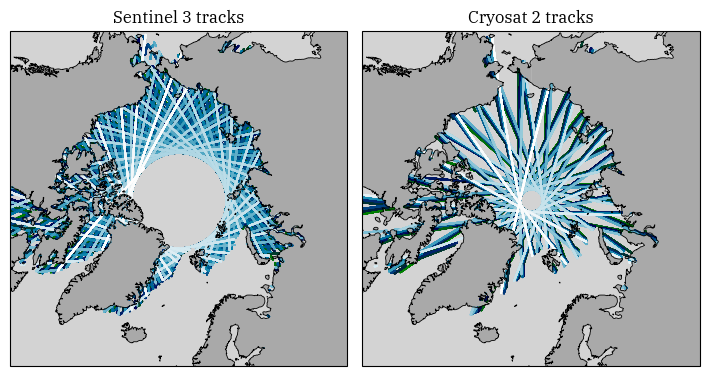

In [9]:
#plot all points within certain dates as a visualisation

dates = ['2020-01-01', '2020-01-02','2020-01-03','2020-01-04', '2019-12-31','2019-12-30', '2019-12-29','2019-12-28']

lon_sen3 = cs2s3['lon'].loc[(cs2s3['satellite_name'] == 'sentinel3') & (cs2s3['date_string'].isin(dates))]
lat_sen3 = cs2s3['lat'].loc[(cs2s3['satellite_name'] == 'sentinel3') & (cs2s3['date_string'].isin(dates))]
tracks_sen3 = cs2s3['Track'].loc[(cs2s3['satellite_name'] == 'sentinel3') & (cs2s3['date_string'].isin(dates))]

#plot tracks
lon_cs2 = cs2s3['lon'].loc[(cs2s3['satellite_name'] == 'cs2') & (cs2s3['date_string'].isin(dates))]
lat_cs2 = cs2s3['lat'].loc[(cs2s3['satellite_name'] == 'cs2') & (cs2s3['date_string'].isin(dates))]
tracks_cs2 = cs2s3['Track'].loc[(cs2s3['satellite_name'] == 'cs2') & (cs2s3['date_string'].isin(dates))]

proj = ccrs.NorthPolarStereo()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    subplot_kw={'projection' : proj},
    figsize=(7.2, 4.0)
)

ax1.set_title('Sentinel 3 tracks')
ax1.set_extent([-180,180, 60,90],crs=ccrs.PlateCarree())

ax1.add_feature(cfeat.OCEAN, facecolor = 'lightgrey')
ax1.add_feature(cfeat.LAND, facecolor = 'darkgrey')
ax1.add_feature(cfeat.COASTLINE, linewidth=0.6)

sc = ax1.scatter(lon_sen3,lat_sen3,c=tracks_sen3,s=0.1, transform=ccrs.PlateCarree(), cmap = 'ocean')

ax2.set_title('Cryosat 2 tracks')
ax2.set_extent([-180,180, 60,90],crs=ccrs.PlateCarree())

ax2.add_feature(cfeat.OCEAN, facecolor = 'lightgrey')
ax2.add_feature(cfeat.LAND, facecolor = 'darkgrey')
ax2.add_feature(cfeat.COASTLINE, linewidth=0.6)

sc = ax2.scatter(lon_cs2,lat_cs2,c=tracks_cs2,s=0.1, transform=ccrs.PlateCarree(), cmap = 'ocean')

plt.tight_layout()

plt.show()

In [10]:
#put relevant data in one df with standardised labels
data_df = pd.DataFrame({
    'x' : cs2s3['x'],
    'y' : cs2s3['y'],
    'lon' : cs2s3['lon'],
    'lat' : cs2s3['lat'],
    't' : cs2s3['t'],
    'z' : cs2s3['SLA'],
    'track' : cs2s3['Track'],
    'date_string': cs2s3['date_string'],
    'sea_ice' : cs2s3['Sea_Ice_Class'],
    'lead' : cs2s3['Lead_Class'],
    'satellite' : cs2s3['satellite_name']

})

We can filter based on the sea ice and lead class, removing invalid points, (both 0 or 1), and then changing the denotion to be a lead mask. Then, based on our filtering, every point outside of this mask is an ice floe instead of open ocean.

In [11]:
print(data_df.head())

               x              y        lon        lat        t   z  track  \
2 -636545.914921 -532921.440470 -50.063655  82.561743  18231.0 NaN      2   
3 -636377.309702 -532668.339181 -50.069581  82.564361  18231.0 NaN      2   
4 -635871.450745 -531908.999571 -50.087384  82.572215  18231.0 NaN      2   
5 -635702.819591 -531655.870900 -50.093327  82.574833  18231.0 NaN      2   
6 -635196.853847 -530896.483464 -50.111178  82.582687  18231.0 NaN      2   

  date_string  sea_ice  lead satellite  
2  2019-12-01      1.0   0.0       cs2  
3  2019-12-01      1.0   0.0       cs2  
4  2019-12-01      1.0   0.0       cs2  
5  2019-12-01      1.0   0.0       cs2  
6  2019-12-01      0.0   0.0       cs2  


In [12]:
#filter to only include positively identified sea ice and leads
invalid_mask = data_df['lead'] == data_df['sea_ice']

data_df = data_df[~invalid_mask]

#then create a lead mask and remove sea ice class
data_df['lead_mask']  = (data_df['lead'] == 1.0).astype(float)
data_df = data_df.drop(columns=['lead','sea_ice'])

print('Points removed: ', len(invalid_mask))
print('Points kept: ', len(data_df))

Points removed:  24681062
Points kept:  19493900


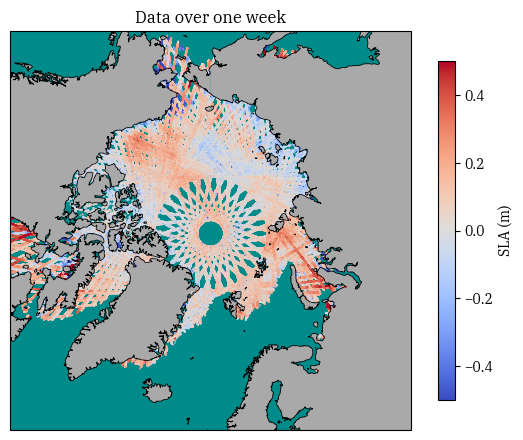

In [13]:
#show data
dates = ['2020-01-01', '2020-01-02','2020-01-03','2020-01-04', '2020-01-05','2020-01-06', '2020-01-07']

lon = data_df['lon'].loc[data_df['date_string'].isin(dates)]
lat = data_df['lat'].loc[data_df['date_string'].isin(dates)]
tracks = data_df['track'].loc[data_df['date_string'].isin(dates)]
sla = data_df['z'].loc[data_df['date_string'].isin(dates)]

proj = ccrs.NorthPolarStereo()

fig, ax = plt.subplots(
    subplot_kw={'projection' : proj},
    figsize=(7.0, 4.5)
)

ax.set_title('Data over one week')

ax.set_extent([-180, 180, lat.min(),lat.max()],crs=ccrs.PlateCarree())

ax.add_feature(cfeat.OCEAN, facecolor = 'darkcyan')
ax.add_feature(cfeat.LAND, facecolor = 'darkgrey')
ax.add_feature(cfeat.COASTLINE, linewidth=0.6)

sc = ax.scatter(lon,lat,c=sla,s=0.1, vmin=-0.5,vmax=0.5, transform=ccrs.PlateCarree(), cmap = 'coolwarm')


cbar = fig.colorbar(
    sc,
    ax=ax,
    orientation='vertical',
    pad=0.04,
    shrink=0.85
)
cbar.set_label('SLA (m)')


plt.tight_layout()

plt.show()

In [14]:
print(f'Num. datapoints: {len(data_df)}')
print(f"Num. tracks: {len(data_df['track'].unique())}")

Num. datapoints: 19493900
Num. tracks: 14188


Next, run the calculation of the distance along the track for every Jan 2020 track in the dataset.

In [15]:
#iterate over tracks
track_list = data_df['track'].unique()
print(f'Number of tracks: {len(track_list)}')

tracks_in_date = []
print('Checking tracks are in date...')
for track in track_list:
    track_df = data_df[data_df['track']==track].copy()
    track_date_str = track_df['date_string'].iloc[0]

    if target_month in track_date_str:
        tracks_in_date.append(track)

print(f'Tracks in target date: {len(tracks_in_date)}')

full_df = pd.DataFrame()

print('Calculating track lengths and adding to final...')
for i, track in enumerate(tracks_in_date):
    print(f'Processing track {track}, {i+1} of {len(tracks_in_date)}...')
    track_df = data_df[data_df['track']==track].copy()
    if len(track_df[track_df['lead_mask']== 1.]) < 10:
        print(f'Track {track} datapoints not sufficient, skipping (<10)...')
        continue

    lat = track_df['lat']
    lon = track_df['lon']

    Xs = np.column_stack([lon, lat])

    # Build consecutive pairs: (0->1), (1->2), ..., (N-2 -> N-1)
    A = Xs[:-1]
    B = Xs[1:]

    # Use GCdist to get the distance matrix for these pairs
    # Then take the diagonal to get distances of consecutive segments
    seg_matrix = GCdist(A, B)        # shape (N-1, N-1)
    seg_d = np.diag(seg_matrix)      # shape (N-1,), distances in metres

    # Cumulative along-track distance (0 at start)
    cum_dist = np.concatenate(([0.0], np.cumsum(seg_d)))
    track_df['dist_along_track'] = cum_dist

    full_df = pd.concat([full_df, track_df])
    
    print('Track added.')

print('All tracks added!')

Number of tracks: 14188
Checking tracks are in date...
Tracks in target date: 4743
Calculating track lengths and adding to final...
Processing track 1243, 1 of 4743...
Track added.
Processing track 1244, 2 of 4743...
Track added.
Processing track 1245, 3 of 4743...
Track added.
Processing track 1246, 4 of 4743...
Track added.
Processing track 1247, 5 of 4743...
Track added.
Processing track 1248, 6 of 4743...
Track added.
Processing track 1249, 7 of 4743...
Track added.
Processing track 1250, 8 of 4743...
Track added.
Processing track 1251, 9 of 4743...
Track added.
Processing track 1252, 10 of 4743...
Track added.
Processing track 1253, 11 of 4743...
Track added.
Processing track 1254, 12 of 4743...
Track added.
Processing track 1255, 13 of 4743...
Track added.
Processing track 1256, 14 of 4743...
Track added.
Processing track 1257, 15 of 4743...
Track added.
Processing track 1258, 16 of 4743...
Track added.
Processing track 1259, 17 of 4743...
Track added.
Processing track 1260, 18 o

In [16]:
final_df = pd.merge(
    data_df,
    full_df,
    how = 'outer',
    left_on = ['x','y','lon','lat','t','z', 'track', 'date_string', 'lead_mask', 'satellite'],
    right_on  = ['x','y','lon','lat','t','z', 'track', 'date_string', 'lead_mask', 'satellite']
)
final_df.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track
0,-636545.914921,-532921.440470,-50.063655,82.561743,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN
1,-636377.309702,-532668.339181,-50.069581,82.564361,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN
2,-635871.450745,-531908.999571,-50.087384,82.572215,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN
3,-635702.819591,-531655.870900,-50.093327,82.574833,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN
4,-635028.186715,-530643.339197,-50.117137,82.585305,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN


### Outliers
Next we look for outliers in the dataset to remove. This includes individual datapoints with an absolute value above 20, and tracks with an average value above/below $\pm$ 0.5.

In [17]:
final_df['z_track_avg'] = final_df.groupby('track')['z'].transform('mean')

final_df.head()

#first remove individual values of absolute value >20m
print(f'Total datapoints: {len(final_df)}')
outlier_value_mask = final_df['z'].abs() > 20

final_df_outliers = final_df[outlier_value_mask]
final_df = final_df[~outlier_value_mask]

print(f'Outliers removed: {len(final_df_outliers)}')
print(f'Remaining datapoints: {len(final_df)}')

Total datapoints: 19493900
Outliers removed: 0
Remaining datapoints: 19493900


               x              y        lon        lat        t   z  track  \
0 -636545.914921 -532921.440470 -50.063655  82.561743  18231.0 NaN      2   
1 -636377.309702 -532668.339181 -50.069581  82.564361  18231.0 NaN      2   
2 -635871.450745 -531908.999571 -50.087384  82.572215  18231.0 NaN      2   
3 -635702.819591 -531655.870900 -50.093327  82.574833  18231.0 NaN      2   
4 -635028.186715 -530643.339197 -50.117137  82.585305  18231.0 NaN      2   

  date_string satellite  lead_mask  dist_along_track  z_track_avg  
0  2019-12-01       cs2        0.0               NaN     0.171957  
1  2019-12-01       cs2        0.0               NaN     0.171957  
2  2019-12-01       cs2        0.0               NaN     0.171957  
3  2019-12-01       cs2        0.0               NaN     0.171957  
4  2019-12-01       cs2        0.0               NaN     0.171957  


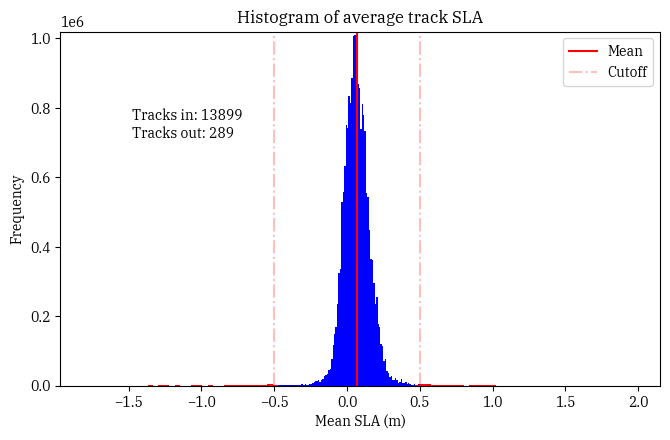

In [18]:
track_avgs = final_df['z_track_avg']
track_avgs_avg = track_avgs.mean()

outlier_mask = (track_avgs.abs() > 0.5)

track_avgs_outliers = track_avgs.loc[outlier_mask]
track_avgs_inliers = track_avgs.loc[~outlier_mask]

outliers_df = final_df.loc[outlier_mask]
inliers_df = final_df.loc[~outlier_mask]

num_outliers = len(outliers_df['track'].unique())
num_inliers = len(inliers_df['track'].unique())

fig, ax = plt.subplots(figsize = (6.8, 4.5))

counts1, bins1, patches1 = ax.hist(track_avgs_inliers, bins = 100, zorder=0, color = 'b')
counts2, bins2, patches2 = ax.hist(track_avgs_outliers, bins = 100, zorder=0, color = 'r')


ax.set_title('Histogram of average track SLA')
ax.set_ylabel('Frequency')
ax.set_xlabel('Mean SLA (m)')
ax.axvline(track_avgs_avg, color = 'red', zorder = 2, label = 'Mean')
ax.axvline(-0.5,color = 'red', zorder = 2, alpha=0.25, linestyle='-.', label = 'Cutoff')
ax.axvline(0.5,color = 'red', zorder = 2, alpha=0.25, linestyle='-.')
ax.set_ylim(0, max(counts1)+10000)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(x=(3/4)*xmin, y=(3/4)*ymax, s=f'Tracks in: {num_inliers}')
ax.text(x=(3/4)*xmin, y=(2.8/4)*ymax, s=f'Tracks out: {num_outliers}')
ax.legend(loc=1)

print(inliers_df.head())

plt.tight_layout()
plt.show()

In [19]:
inliers_df.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
0,-636545.914921,-532921.440470,-50.063655,82.561743,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN,0.171957
1,-636377.309702,-532668.339181,-50.069581,82.564361,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN,0.171957
2,-635871.450745,-531908.999571,-50.087384,82.572215,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN,0.171957
3,-635702.819591,-531655.870900,-50.093327,82.574833,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN,0.171957
4,-635028.186715,-530643.339197,-50.117137,82.585305,18231.0,NaN,2,2019-12-01,cs2,0.0,NaN,0.171957


In [20]:
#finally, save the data in a csv
inliers_df.to_csv('/home/mhen/geol0069_data/jan20.csv', index=False)